In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
df = pd.read_csv('youtube_cleaned_text.csv')

Saving youtube_cleaned_text.csv to youtube_cleaned_text.csv


In [ ]:
from collections import Counter

all_words = ' '.join(df['transcript_cleaned'].dropna()).split()
word_counts = Counter(all_words)

print(word_counts.most_common(15))

[('hour', 5), ('warehouse', 5), ('work', 4), ('im', 4), ('hours', 3), ('month', 3), ('job', 3), ('really', 3), ('truck', 3), ('pay', 2), ('overtime', 2), ('three', 2), ('amazon', 2), ('worker', 2), ('jobs', 2)]


In [ ]:
stop_keywords = ['work', 'im', 'job', 'jobs', 'really', 'amazon']
filtered_words = [word for word in all_words if word not in stop_keywords]
filtered_counts = Counter(filtered_words)

print(filtered_counts.most_common(15))

[('hour', 5), ('warehouse', 5), ('hours', 3), ('month', 3), ('truck', 3), ('pay', 2), ('overtime', 2), ('three', 2), ('worker', 2), ('around', 2), ('body', 2), ('boring', 2), ('10', 2), ('important', 2), ('organize', 2)]


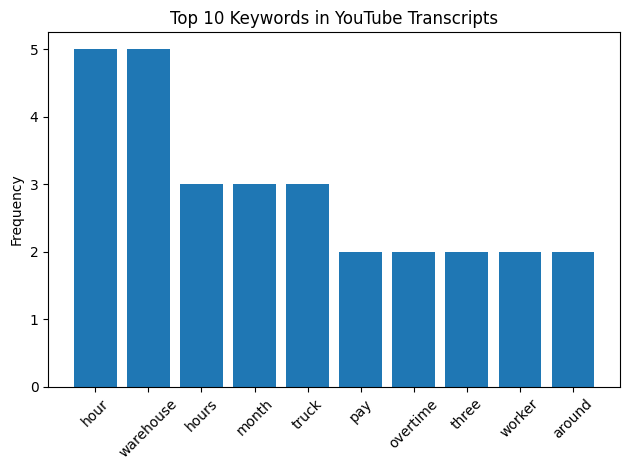

In [ ]:
import matplotlib.pyplot as plt

most_common = filtered_counts.most_common(10)
words, counts = zip(*most_common)

plt.bar(words, counts)
plt.title("Top 10 Keywords in YouTube Transcripts")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
from nltk.util import ngrams

bigrams = list(ngrams(filtered_words, 2))
bigram_counts = Counter(bigrams)

print(bigram_counts.most_common(10))

[(('important', 'organize'), 2), (('organize', 'ever'), 2), (('bus', 'ride'), 2), (('base', 'pay'), 1), (('pay', '1850'), 1), (('1850', 'hour'), 1), (('hour', 'overtime'), 1), (('overtime', 'pay'), 1), (('pay', '2750'), 1), (('2750', 'hour'), 1)]


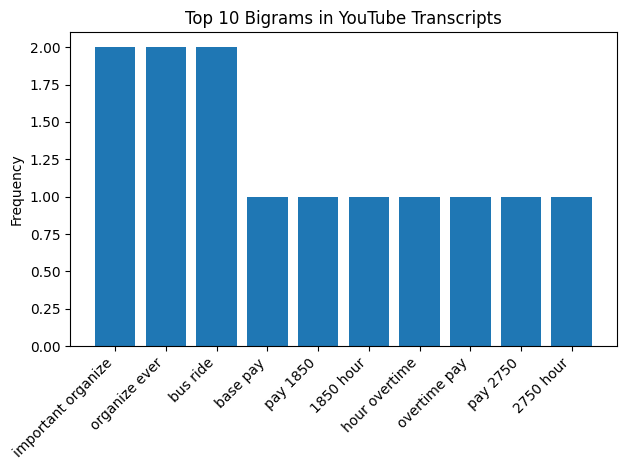

In [ ]:
common_bigrams = bigram_counts.most_common(10)
bg_labels = [' '.join(bg) for bg, count in common_bigrams]
bg_counts = [count for bg, count in common_bigrams]

plt.bar(bg_labels, bg_counts)
plt.title("Top 10 Bigrams in YouTube Transcripts")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
trigrams = list(ngrams(filtered_words, 3))
trigram_counts = Counter(trigrams)
print(trigram_counts.most_common(10))

[(('important', 'organize', 'ever'), 2), (('base', 'pay', '1850'), 1), (('pay', '1850', 'hour'), 1), (('1850', 'hour', 'overtime'), 1), (('hour', 'overtime', 'pay'), 1), (('overtime', 'pay', '2750'), 1), (('pay', '2750', 'hour'), 1), (('2750', 'hour', 'worked'), 1), (('hour', 'worked', '60'), 1), (('worked', '60', 'hours'), 1)]


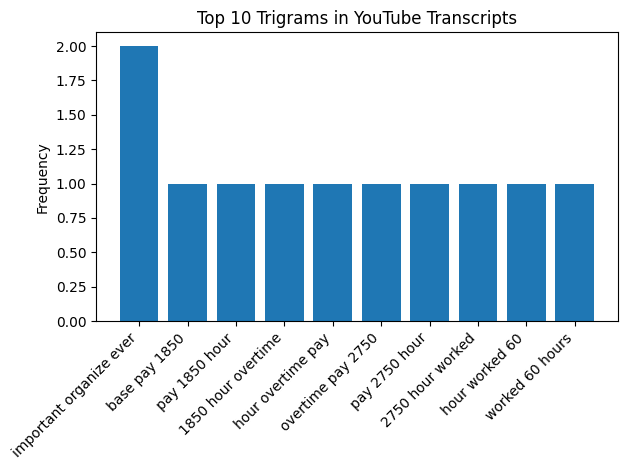

In [ ]:
common_trigrams = trigram_counts.most_common(10)
tg_labels = [' '.join(tg) for tg, count in common_trigrams]
tg_counts = [count for tg, count in common_trigrams]

plt.bar(tg_labels, tg_counts)
plt.title("Top 10 Trigrams in YouTube Transcripts")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

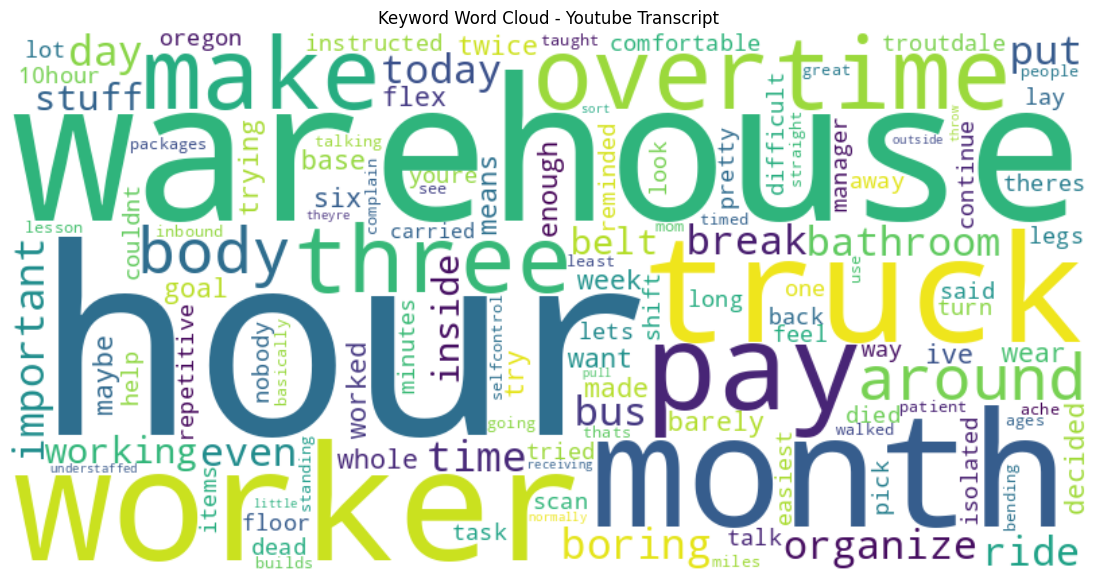

In [ ]:
!pip install wordcloud
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(filtered_words))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Keyword Word Cloud - Youtube Transcript")
plt.show()